# Bean Disease Classifier
This model aims to tweak the model architecture from the first version of the bean classifier. For this Version ill use global average pooling without a dropout layer

In [1]:
# Do not change this code
try:
  # %tensorflow_version only exists in Colab.
  %tensorflow_version 2.x
except Exception:
  pass

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [2]:
# Do not change this code
#gdown for bypassing virus links from google drive
#used for downloading large datasets into cloud environments like google colab
!pip install --upgrade --no-cache-dir gdown

In [3]:
# Do not change this code
#Loading data set from cloud storage(googleapis) into temporary path tmp
#-o short for output where to save the output
!gdown "https://storage.googleapis.com/learning-datasets/beans/train.zip" -O /tmp/train.zip
!gdown "https://storage.googleapis.com/learning-datasets/beans/validation.zip" -O /tmp/validation.zip
!gdown "https://storage.googleapis.com/learning-datasets/beans/test.zip" -O /tmp/test.zip

Downloading...
From: https://storage.googleapis.com/learning-datasets/beans/train.zip
To: /tmp/train.zip
100% 144M/144M [00:01<00:00, 141MB/s]
Downloading...
From: https://storage.googleapis.com/learning-datasets/beans/validation.zip
To: /tmp/validation.zip
100% 18.5M/18.5M [00:00<00:00, 66.1MB/s]
Downloading...
From: https://storage.googleapis.com/learning-datasets/beans/test.zip
To: /tmp/test.zip
100% 17.7M/17.7M [00:00<00:00, 90.2MB/s]


In [7]:
# Do not change this code
import os
import zipfile

#extracting images from the training zipfiles
local_zip = '/tmp/train.zip'
open_zip = zipfile.ZipFile(local_zip,'r')
extracted_zip = open_zip.extractall('/tmp')

#extracting images from the validation zipfiles
local_zip = '/tmp/validation.zip'
open_zip = zipfile.ZipFile(local_zip,'r')
extracted_zip = open_zip.extractall('/tmp/validation')

#extracting images from the test zipfiles
local_zip = '/tmp/test.zip'
open_zip = zipfile.ZipFile(local_zip,'r')
extracted_zip = open_zip.extractall('/tmp/test')


#TRAIN_DIRECTORY_LOCATION

In [9]:
train_image = os.listdir('/tmp/train')
print(train_image)

['bean_rust', 'angular_leaf_spot', 'healthy']


# VALIDATION_DIRECTORY_LOCATION


In [10]:
validation_images = os.listdir('/tmp/validation/validation')
print(validation_images)

['bean_rust', 'angular_leaf_spot', 'healthy']


Now you need to define a generator to process the data we have loaded in Colab so that our model can use it for training. As we showed in the previous video you'll first have to define an ```ImageDataGenerator``` and then flow the data into it.

*A hint: You don't want abnormal data!*

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Creating Generator fir transforming the images to enable the model to generalize better

train_datagen = ImageDataGenerator(
      rescale=1./255, #normalizing images
      rotation_range=40,
      width_shift_range=0.2,
      height_shift_range=0.2,
      shear_range=0.2,
      zoom_range=0.2,
      horizontal_flip=True,
      fill_mode='nearest'

)

validation_datagen = ImageDataGenerator(rescale = 1./255

)

TRAIN_DIRECTORY_LOCATION = '/tmp/train'
VAL_DIRECTORY_LOCATION = '/tmp/validation/validation'
TARGET_SIZE = (224, 224)
CLASS_MODE = 'categorical'

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIRECTORY_LOCATION,
    target_size = TARGET_SIZE,
    batch_size = 128,
    class_mode = CLASS_MODE
)

validation_generator = validation_datagen.flow_from_directory(
    VAL_DIRECTORY_LOCATION,
    target_size = TARGET_SIZE,
    batch_size = 128,
    class_mode = CLASS_MODE
)

Found 1034 images belonging to 3 classes.
Found 133 images belonging to 3 classes.


# Finding out shape

In [15]:
image = '/tmp/train/healthy'
list_image = os.listdir(image)
print(list_image[:1])
x = '/tmp/train/healthy/healthy_train.318.jpg' #image path

['healthy_train.318.jpg']


In [16]:
from tensorflow.keras.preprocessing.image import load_img,img_to_array
from PIL import Image

x = load_img(x, target_size= (224,224)) #loading the image
#x = Image.open(x)
image1= img_to_array(x)


In [17]:
shape = image1.shape

# Visualizing healthy Bean Plant

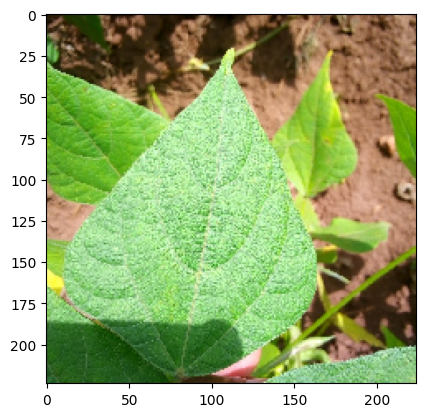

In [18]:
import matplotlib.pyplot as plt
plt.imshow(x)

# Visualizing Unhealthy Bean plant('bean_rust')

In [20]:
image_path = '/tmp/train/bean_rust'
example = os.listdir(image_path)
print(example[:6])
full_path = os.path.join(image_path, 'bean_rust_train.187.jpg')

['bean_rust_train.181.jpg', 'bean_rust_train.308.jpg', 'bean_rust_train.69.jpg', 'bean_rust_train.332.jpg', 'bean_rust_train.151.jpg', 'bean_rust_train.187.jpg']


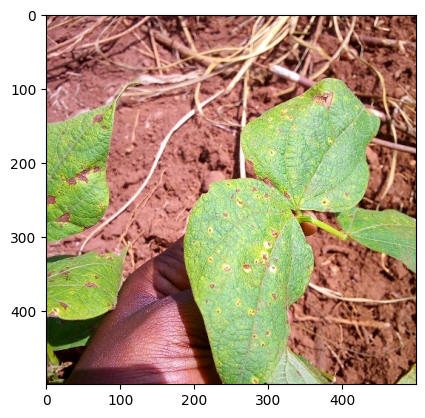

In [21]:
x = load_img(full_path)
plt.imshow(x)

# Visualizing angular_leaf_spot'

In [22]:
image_path = '/tmp/validation/validation/angular_leaf_spot'
example = os.listdir(image_path)
print(example[:2])
full_path = os.path.join(image_path, 'angular_leaf_spot_val.40.jpg')

['angular_leaf_spot_val.3.jpg', 'angular_leaf_spot_val.40.jpg']


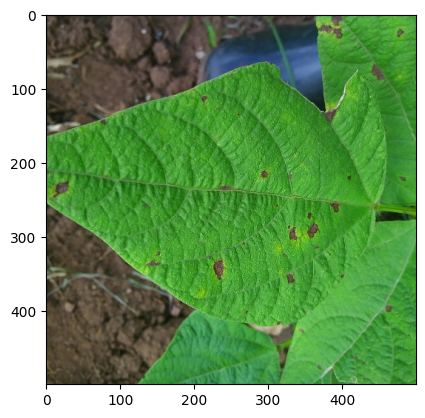

In [23]:
x = load_img(full_path)
plt.imshow(x)

Now its your turn to define a model to learn this data.

*A hint: Like with the CIFAR-10 assignment, your model may want to learn some high level features and then classify them. This time it may help to make the model a little wider at times.*

# Convolution Architecture

In [24]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAvgPool2D, Dense, Dropout, Flatten

model = Sequential()
conv1 = Conv2D(32,(3,3),input_shape = shape,activation ='relu')
mpool1 = MaxPooling2D((2,2))
conv2 = Conv2D(64,(3,3),activation ='relu')
mpool2 = MaxPooling2D((2,2))
conv3= Conv2D(128,(3,3),activation ='relu')
mpool3 = MaxPooling2D((2,2))
conv4= Conv2D(256,(3,3),activation ='relu')
mpool4 = MaxPooling2D((2,2))
Gpool_layer = GlobalAvgPool2D()

model.add(conv1)
model.add(mpool1)
model.add(conv2)
model.add(mpool2)
model.add(conv3)
model.add(mpool3)
model.add(conv4)
model.add(mpool4)
model.add(Gpool_layer)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Convolution Network Summary

In [25]:
# This will print a summary of your model when you're done!
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 388,416 (1.48 MB)

 Trainable params: 388,416 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

# Dense Network Architecture

# Benefit of Dropout

By randomly dropping out neurons, the network cannot rely too heavily on any single neuron or a small set of neurons. This forces other neurons to learn more robust features and prevents complex co-adaptations between neurons that might only work for the training data.

In [26]:
Dense1 = Dense(256,activation = 'relu')
#Dropout_layer = Dropout(0.5)# minimizes overfitting
Prediction_layer = Dense(3,activation= 'softmax')

In [28]:
model.add(Dense1)
#model.add(Dropout_layer)
model.add(Prediction_layer)

# Final Model Architecture and Summary

In [29]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 454,979 (1.74 MB)

 Trainable params: 454,979 (1.74 MB)

 Non-trainable params: 0 (0.00 B)

Then you'll need to pick an appropriate loss function and optimizer.

*A hint: remember we are classifying again.*

In [30]:
LOSS_FUNCTION = 'categorical_crossentropy'
OPTIMIZER = 'adam'

model.compile(
    loss = LOSS_FUNCTION,
    optimizer = OPTIMIZER,
    metrics = ['accuracy']
)

Finally select the number of epochs you'd like to train for and train your model!

*A hint: something in the low tens is a good place to start*

In [31]:
NUM_EPOCHS = 20 #YOUR CODE HERE#

history = model.fit(
      train_generator,
      epochs = NUM_EPOCHS,
      verbose = 1,
      validation_data = validation_generator)



Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.3830 - loss: 1.0940 - val_accuracy: 0.4286 - val_loss: 1.0663
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.4584 - loss: 1.0501 - val_accuracy: 0.4662 - val_loss: 0.9205
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.4768 - loss: 0.9881 - val_accuracy: 0.5489 - val_loss: 0.9080
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.5368 - loss: 0.9461 - val_accuracy: 0.5564 - val_loss: 0.8925
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.5754 - loss: 0.9090 - val_accuracy: 0.6165 - val_loss: 0.8367
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.5706 - loss: 0.9316 - val_accuracy: 0.6692 - val_loss: 0.8011
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.5503 - loss: 0.9621 - val_accuracy: 0.3684 - val_loss: 1.0249
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.5184 - loss: 0.9849 - val_accuracy: 0.6391 - val_loss: 0.8731
Epoch 9/

# Model Evaluation

In [32]:
TEST_DIRECTORY_LOCATION = '/tmp/test/test'
print(os.listdir(TEST_DIRECTORY_LOCATION))
test_datagen = ImageDataGenerator(rescale= 1./255)
test_generator= test_datagen.flow_from_directory(TEST_DIRECTORY_LOCATION,target_size=(224,224),batch_size =32,class_mode='categorical')
model.evaluate(test_generator)

['bean_rust', 'angular_leaf_spot', 'healthy']
Found 128 images belonging to 3 classes.
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.6953 - loss: 0.7218


[0.7217689752578735, 0.6953125]

# Conclusion
Accuracy on test data 69.53%
Loss on test data 72.18%

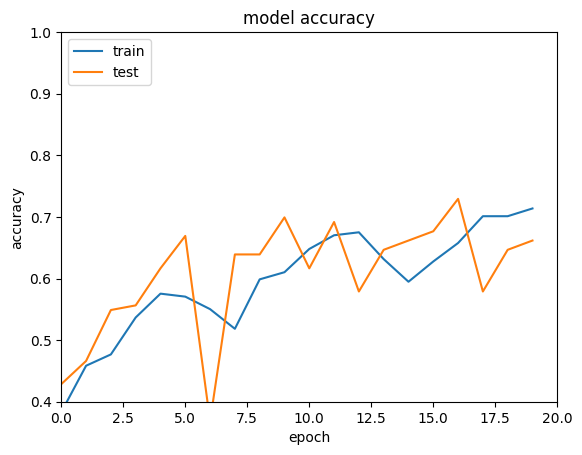

In [33]:
# summarize history for accuracy
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.xlim([0,NUM_EPOCHS])
plt.ylim([0.4,1.0])
plt.show()